<a href="https://colab.research.google.com/github/WickedSero/_CDV_MachineLearning/blob/main/ML_zadanie_4_pingwiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
df_encoded.to_csv('pingwiny_encoded.csv', index=False)

In [ ]:
df_encoded = pd.read_csv('/content/pingwiny_encoded.csv', sep= ';')

## Wczytaj niezbędne biblioteki

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
import plotly.express as px

## Wczytaj dane, zapoznaj się z nimi i je oczyść

In [ ]:
df = pd.read_csv('/content/pingwiny2.csv', sep= ';')

In [ ]:
df.sample(5)

,gatunek,wyspa,dlugosc_dzioba_mm,szerokosc_dzioba_mm,dlugosc_pletwy_mm,masa_ciala_g,plec
87,Pingwin bialobrewy (Pygoscelis papua),Biscoe,"44,5","14,3",216,4100,NaN
50,Pingwin bialobrewy (Pygoscelis papua),Biscoe,"47,2","13,7",214,4925,SAMICA
320,Pingwin maskowy (Pygoscelis antarctica),Dream,"49,7","18,6",195,3600,SAMIEC
309,Pingwin maskowy (Pygoscelis antarctica),Dream,"51,3","19,9",198,3700,SAMIEC
143,Pingwin Adeli (Pygoscelis adeliae),Biscoe,"37,8",20,190,4250,SAMIEC


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   gatunek              342 non-null    object
 1   wyspa                342 non-null    object
 2   dlugosc_dzioba_mm    342 non-null    object
 3   szerokosc_dzioba_mm  342 non-null    object
 4   dlugosc_pletwy_mm    342 non-null    int64 
 5   masa_ciala_g         342 non-null    int64 
 6   plec                 333 non-null    object
dtypes: int64(2), object(5)
memory usage: 18.8+ KB
None


W kolumnie płeć, mamy 9 obserwacji z nullem. Dla ułatwienia dalszych operacji, usuwam je.

In [ ]:
df = df.dropna()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 341
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   gatunek              333 non-null    object
 1   wyspa                333 non-null    object
 2   dlugosc_dzioba_mm    333 non-null    object
 3   szerokosc_dzioba_mm  333 non-null    object
 4   dlugosc_pletwy_mm    333 non-null    int64 
 5   masa_ciala_g         333 non-null    int64 
 6   plec                 333 non-null    object
dtypes: int64(2), object(5)
memory usage: 20.8+ KB
None


In [ ]:
# Konwersja typu kolumn 'dlugosc_dzioba_mm' oraz 'szerokosc_dzioba_mm' na string
df['dlugosc_dzioba_mm'] = df['dlugosc_dzioba_mm'].astype(str)
df['szerokosc_dzioba_mm'] = df['szerokosc_dzioba_mm'].astype(str)

# Zamiana przecinków na kropki oraz konwersja na float
df['dlugosc_dzioba_mm'] = df['dlugosc_dzioba_mm'].str.replace(',', '.').astype(float)
df['szerokosc_dzioba_mm'] = df['szerokosc_dzioba_mm'].str.replace(',', '.').astype(float)

# Konwersja pozostałych kolumn na odpowiednie typy
df['gatunek'] = df['gatunek'].astype('category')
df['wyspa'] = df['wyspa'].astype('category')
df['plec'] = df['plec'].astype('category')

In [ ]:
# Sprawdzenie wyników
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 341
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gatunek              333 non-null    category
 1   wyspa                333 non-null    category
 2   dlugosc_dzioba_mm    333 non-null    float64 
 3   szerokosc_dzioba_mm  333 non-null    float64 
 4   dlugosc_pletwy_mm    333 non-null    int64   
 5   masa_ciala_g         333 non-null    int64   
 6   plec                 333 non-null    category
dtypes: category(3), float64(2), int64(2)
memory usage: 14.4 KB
None


Kolumy informujące o gatunku, wyspie, i płci są danymi kategorycznymi. Typ danych dla kolumny ustawiony jest zatep jako 'category'.
Pozostałe dane to wartości liczbowe, w zależności, czy dane są zmiennoprzeciwnkowe, czy nie ustawiony jest odpowiedni typ kolumny, czyli float i int.

In [ ]:
df.head(5)

,gatunek,wyspa,dlugosc_dzioba_mm,szerokosc_dzioba_mm,dlugosc_pletwy_mm,masa_ciala_g,plec
0,Pingwin bialobrewy (Pygoscelis papua),Biscoe,42.0,13.5,210,4150,SAMICA
1,Pingwin bialobrewy (Pygoscelis papua),Biscoe,46.5,13.5,210,4550,SAMICA
2,Pingwin bialobrewy (Pygoscelis papua),Biscoe,47.5,14.0,212,4875,SAMICA
3,Pingwin bialobrewy (Pygoscelis papua),Biscoe,43.3,14.0,208,4575,SAMICA
4,Pingwin bialobrewy (Pygoscelis papua),Biscoe,45.5,14.5,212,4750,SAMICA


In [ ]:
print(df['gatunek'].unique())
print(df['wyspa'].unique())
print(df['plec'].unique())

['Pingwin bialobrewy (Pygoscelis papua)', 'Pingwin Adeli (Pygoscelis adeliae)', 'Pingwin maskowy (Pygoscelis antarctica)']
Categories (3, object): ['Pingwin Adeli (Pygoscelis adeliae)', 'Pingwin bialobrewy (Pygoscelis papua)',
                         'Pingwin maskowy (Pygoscelis antarctica)']
['Biscoe', 'Dream', 'Torgersen']
Categories (3, object): ['Biscoe', 'Dream', 'Torgersen']
['SAMICA', 'SAMIEC']
Categories (2, object): ['SAMICA', 'SAMIEC']


Ponieważ kolumny gatunek, wyspa oraz płeć to zmienne kategoryczne, na potrzeby modelowania regresji liniowej zastosujemy one-hot encoding.

In [ ]:
df_encoded = pd.get_dummies(df, columns=['gatunek', 'wyspa', 'plec'], drop_first=False)

In [ ]:
# Konwersja zmiennych bool na zmienne typu int
df_encoded = df_encoded.astype({col: 'int' for col in df_encoded.select_dtypes(include=['bool']).columns})

In [ ]:
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 341
Data columns (total 12 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   dlugosc_dzioba_mm                                333 non-null    float64
 1   szerokosc_dzioba_mm                              333 non-null    float64
 2   dlugosc_pletwy_mm                                333 non-null    int64  
 3   masa_ciala_g                                     333 non-null    int64  
 4   gatunek_Pingwin Adeli (Pygoscelis adeliae)       333 non-null    int64  
 5   gatunek_Pingwin bialobrewy (Pygoscelis papua)    333 non-null    int64  
 6   gatunek_Pingwin maskowy (Pygoscelis antarctica)  333 non-null    int64  
 7   wyspa_Biscoe                                     333 non-null    int64  
 8   wyspa_Dream                                      333 non-null    int64  
 9   wyspa_Torgersen                      

In [ ]:
# Zdefiniowanie zmiennej zależnej i niezależnych
X = df_encoded.drop(columns=['masa_ciala_g'])  # Wszystkie kolumny oprócz 'masa_ciala_g'
y = df_encoded['masa_ciala_g']

# Dodanie stałej do modelu (intercept)
X = sm.add_constant(X)

# Stworzenie modelu regresji liniowej
model = sm.OLS(y, X).fit()

# Podsumowanie wyników modelu
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           masa_ciala_g   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     284.1
Date:                Wed, 22 Jan 2025   Prob (F-statistic):          1.85e-141
Time:                        18:02:30   Log-Likelihood:                -2353.6
No. Observations:                 333   AIC:                             4725.
Df Residuals:                     324   BIC:                             4760.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

## Model regresji, który objaśnia zmienność masy ciała pingwina w gramach.

## Analiza wyników

### Model regresji liniowej

Model regresji liniowej zapisany w równaniu:

y = B0 + B1 * X1 + B2 * X2 + B3 * X3 + B4 * X4 + B5 * X5 + B6 * X6 + B7 * X7 + B8 * X8 + ε

### Gdzie:

- B0 to stała (intercept).
- B1, B2, ..., B8 to współczynniki regresji (Beta) odpowiadające poszczególnym zmiennym niezależnym.
- ε to składnik losowy (błąd).

### Podstawiając wartości współczynników z wyników modelu, otrzymujemy:

$$
\text{masa_ciała_g} = -500.46 + 18.19 \cdot \text{długość_dzioba_mm} + 67.58 \cdot \text{szerokość dzioba_mm} + 16.24 \cdot \text{długość_płetwy_mm} - 409.30 \cdot \text{gatunek_Pingwin_Adeli} + 578.46 \cdot \text{gatunek_Pingwin_białobrewy} - 669.61 \cdot \text{gatunek_Pingwin_maskowy} - 443.84 \cdot \text{płeć_SAMICA} - 56.62 \cdot \text{płeć_SAMIEC} + \epsilon
$$


### Interpretacja parametrów Beta (coef):

Parametry Beta określają, jak bardzo dana zmienna niezależna wpływa na zmienną zależną (masa_ciala_g w tym przypadku), przy założeniu, że wszystkie inne zmienne w modelu pozostają stałe.

- **B1 dla `dlugosc_dzioba_mm` = 18.19** oznacza, że wzrost długości dzioba o 1 mm powoduje wzrost masy ciała o 18.19 g.
- **B2 dla `szerokosc_dzioba_mm` = 67.58** oznacza, że wzrost szerokości dzioba o 1 mm powoduje wzrost masy ciała o 67.58 g.
- **B3 dla `dlugosc_pletwy_mm` = 16.24** oznacza, że wzrost długości płetwy o 1 mm powoduje wzrost masy ciała o 16.24 g.
- **B4 dla `gatunek_Pingwin_Adeli` = -409.30** oznacza, że pingwiny Adeli mają średnio o 409.30 g mniejszą masę ciała w porównaniu do referencyjnego gatunku.
- **B5 dla `gatunek_Pingwin_bialobrewy` = 578.46** oznacza, że pingwiny białobrewe mają średnio o 578.46 g większą masę ciała w porównaniu do referencyjnego gatunku.
- **B6 dla `gatunek_Pingwin_maskowy` = -669.61** oznacza, że pingwiny maskowe mają średnio o 669.61 g mniejszą masę ciała w porównaniu do referencyjnego gatunku.
- **B7 dla `plec_SAMICA` = -443.84** oznacza, że samice mają średnio o 443.84 g mniejszą masę ciała w porównaniu do samców.
- **B8 dla `plec_SAMIEC` = -56.62** oznacza, że płeć samca nie ma istotnego wpływu na masę ciała (ponieważ wartość p dla tej zmiennej była wyższa niż 0.05).

## Interpretacja parametru istotność poszczególnych zmiennych Pr(>|t|)

Wartości p dla poszczególnych zmiennych informują nas o istotności statystycznej tych zmiennych w modelu.
Zmienna `plec_SAMIEC` oraz zmienne dotyczące wyspy (`wyspa_Biscoe`, `wyspa_Dream`, `wyspa_Torgersen`) nie są statystycznie istotne, ponieważ ich wartości p są powyżej 0.05. Może to sugerować, że te zmienne nie mają dużego wpływu na masę ciała pingwina w porównaniu do innych zmiennych.

- `gatunek_Pingwin Adeli`: p = 0.000 (istotna zmienna)  
- `gatunek_Pingwin bialobrewy`: p = 0.000 (istotna zmienna)  
- `gatunek_Pingwin maskowy`: p = 0.000 (istotna zmienna)  
- `szerokosc_dzioba_mm`: p = 0.001 (istotna zmienna)  
- `dlugosc_pletwy_mm`: p = 0.000 (istotna zmienna)  
- `plec_SAMICA`: p = 0.001 (istotna zmienna)  
- `plec_SAMIEC`: p = 0.722 (nieistotna zmienna)  
- `wyspa_Biscoe`: p = 0.139 (nieistotna zmienna)  
- `wyspa_Dream`: p = 0.107 (nieistotna zmienna)  
- `wyspa_Torgersen`: p = 0.067 (nieistotna zmienna)

## Interpretacja parametru R-kwadrat

R-squared = 0.875

Oznacza to, że około 87,5% zmienności masy ciała pingwinów można wyjaśnić za pomocą zmiennych w modelu. To dobry wynik, który wskazuje, że model jest dobrze dopasowany do danych.

## Interpretacja wartości p modelu

Prob (F-statistic) = 1.85e-141

Wartość p modelu (F-statistic) jest bardzo mała (bliska zeru), co oznacza, że model jest statystycznie istotny i zmienne w modelu mają znaczenie w wyjaśnianiu zmienności masy ciała.

## Wykres rozrzutu reszt modelu regresji

In [ ]:
# Reszty modelu
residuals = model.resid

# Dopasowane wartości
fitted_values = model.fittedvalues

# Współczynniki regresji
coefficients = model.params

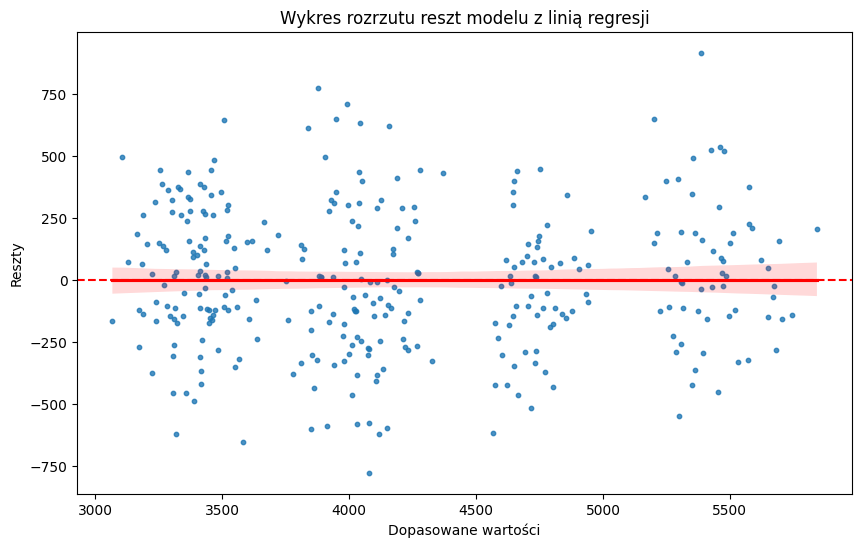

In [ ]:
X = df_encoded.drop(columns=['masa_ciala_g'])
y = df_encoded['masa_ciala_g']

# Dopasowanie modelu OLS
model = sm.OLS(y, X).fit()

# Wykres rozrzutu reszt vs dopasowane wartości
plt.figure(figsize=(10, 6))
sns.regplot(x=fitted_values, y=residuals, scatter_kws={'s': 10}, line_kws={'color': 'red'})
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Dopasowane wartości')
plt.ylabel('Reszty')
plt.title('Wykres rozrzutu reszt modelu z linią regresji')
plt.show()

In [ ]:
print(df_encoded.columns)

Index(['dlugosc_dzioba_mm', 'szerokosc_dzioba_mm', 'dlugosc_pletwy_mm',
       'masa_ciala_g', 'gatunek_Pingwin Adeli (Pygoscelis adeliae)',
       'gatunek_Pingwin bialobrewy (Pygoscelis papua)',
       'gatunek_Pingwin maskowy (Pygoscelis antarctica)', 'wyspa_Biscoe',
       'wyspa_Dream', 'wyspa_Torgersen', 'plec_SAMICA', 'plec_SAMIEC',
       'fitted_values', 'residuals'],
      dtype='object')


Dokonaj predykcji modelu dla przypadku:
*   pingwin maskowy,
*   samiec,
*   długośc dzioba 46 mm,
*   szerokość 21 mm,
*   długość płetwy 210 mm.

In [ ]:
# Przygotowanie danych wejściowych (nowy przypadek)
new_data = {
    'dlugosc_dzioba_mm': [46],              # Długość dzioba w mm
    'szerokosc_dzioba_mm': [21],            # Szerokość dzioba w mm
    'dlugosc_pletwy_mm': [210],             # Długość płetwy w mm
    'gatunek_Pingwin maskowy (Pygoscelis antarctica)': [1],  # Pingwin maskowy
    'gatunek_Pingwin bialobrewy (Pygoscelis papua)': [0],     # Brak Pingwina białobrewego
    'gatunek_Pingwin Adeli (Pygoscelis adeliae)': [0],         # Brak Pingwina Adeli
    'wyspa_Biscoe': [0],                    # Brak wyspy Biscoe
    'wyspa_Torgersen': [0],                 # Brak wyspy Torgersen
    'wyspa_Dream': [0],                     # Brak wyspy Dream
    'plec_SAMICA': [0],                     # Samiec (plec_SAMICA = 0)
    'plec_SAMIEC': [1]                      # Samiec (plec_SAMIEC = 1)
}

# Tworzymy DataFrame z tych danych
new_df = pd.DataFrame(new_data)

# Dodanie stałej do modelu (intercept) dla nowych danych
new_df = sm.add_constant(new_df)

training_columns = model.params.index
new_df = new_df.reindex(columns=training_columns, fill_value=0)


# Dokonanie predykcji za pomocą modelu
prediction = model.predict(new_df)

# Wyświetlenie wyniku predykcji
print(f"Przewidywana masa ciała pingwina: {prediction[0]:.0f} gramów")

Przewidywana masa ciała pingwina: 4582 gramów


## Zbuduj ręcznie dowolny model konkurencyjny:
•	dowolna metoda regresji,
•	dowolne parametry,
•	R2 >= 0.75.

Ponieważ poniższe parametry są statystycznie nieistotne, nie będą służyły do budowania modelu.
*   `plec_SAMIEC`: p = 0.722
*   `wyspa_Biscoe`: p = 0.139
*   `wyspa_Dream`: p = 0.107
*   `wyspa_Torgersen`: p = 0.067


---


Zbuduj ręcznie dowolny model konkurencyjny:

*   dowolna metoda regresji,
*   dowolne parametry,
*   R² >= 0.75.

Tym razem wykorzystam bibliotekę `sklearn`.

In [ ]:
# Przygotowanie danych, eliminując zmienne nieistotne statystycznie
X = df_encoded[['dlugosc_dzioba_mm', 'szerokosc_dzioba_mm', 'dlugosc_pletwy_mm',
                'gatunek_Pingwin Adeli (Pygoscelis adeliae)', 'gatunek_Pingwin bialobrewy (Pygoscelis papua)',
                'gatunek_Pingwin maskowy (Pygoscelis antarctica)',]]

y = df_encoded['masa_ciala_g']

# Normalizacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podział danych na zbiór treningowy i testowy (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Tworzenie modelu regresji liniowej
model = LinearRegression()

# Trenowanie modelu
model.fit(X_train, y_train)

# Predykcje na zbiorze testowym
y_pred = model.predict(X_test)

# Obliczenie R²
r2 = r2_score(y_test, y_pred)

# Wyświetlenie wartości R²
print(f"R² na zbiorze testowym: {r2:.3f}")

R² na zbiorze testowym: 0.893


Po wykluczeniu wyżej wymienionych parametrów wartość R-kwadrat wzrosła z 0.875 na 0.899. Oznacza to, że model jest obecnie lepiej dopasowany dzięki ograniczeniu ilości parametrów.

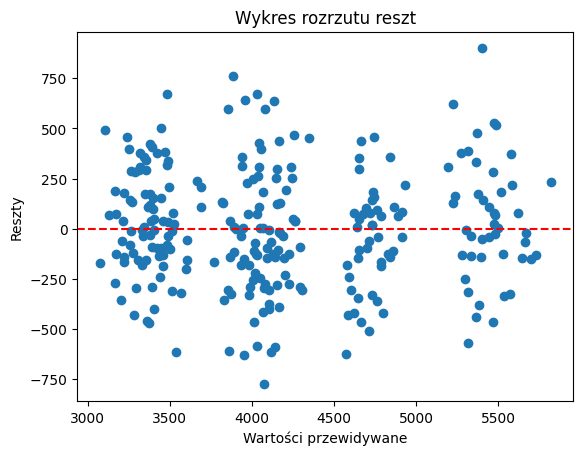

In [ ]:
# Oblicz reszty
residuals = y_train - model.predict(X_train)

# Wykres rozrzutu reszt
plt.scatter(model.predict(X_train), residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Wartości przewidywane')
plt.ylabel('Reszty')
plt.title('Wykres rozrzutu reszt')
plt.show()

In [ ]:
# Dopasowanie modelu na danych treningowych
model = sm.OLS(y_train, X_train).fit()

# Obliczanie reszt
residuals_train = y_train - model.predict(X_train)

# Dodanie stałej do X_train (aby dopasować zgodność)
X_train_const = sm.add_constant(X_train)

# Test Breuscha-Pagana
bp_test = het_breuschpagan(residuals_train, X_train_const)
print('Statystyka Breuscha-Pagana:', bp_test[0])
print('p-wartość Breuscha-Pagana:', bp_test[1])


Statystyka Breuscha-Pagana: 138.29238669551683
p-wartość Breuscha-Pagana: 1.1582174037975187e-26


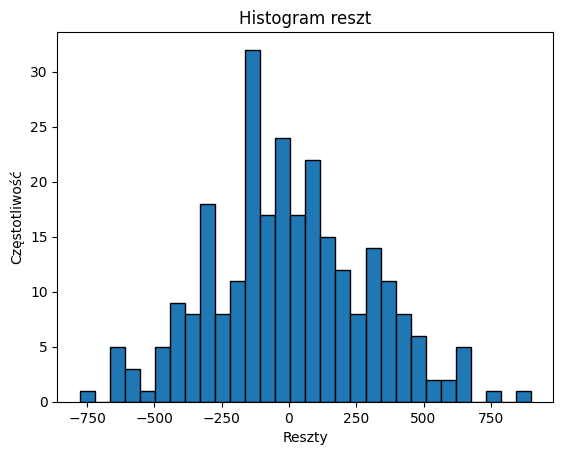

In [ ]:
# Histogram reszt
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Histogram reszt')
plt.xlabel('Reszty')
plt.ylabel('Częstotliwość')
plt.show()

co oznacza ze rozkład reszt nie jest normalny

                            OLS Regression Results                            
Dep. Variable:           masa_ciala_g   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     237.0
Date:                Tue, 14 Jan 2025   Prob (F-statistic):          3.92e-102
Time:                        19:59:47   Log-Likelihood:                 317.10
No. Observations:                 266   AIC:                            -620.2
Df Residuals:                     259   BIC:                            -595.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0484      0.000    408.925      0.0

Wynik testu Breuscha-Pagana wskazuje na wysoką statystykę testową (138.29) oraz bardzo niską p-wartość (1.16e-26), co silnie sugeruje, że istnieje heteroskedastyczność w resztach modelu. Oznacza to, że wariancja (zmienność) reszt nie jest stała, co narusza jedno z kluczowych założeń klasycznej regresji liniowej (homoskedastyczność).

**Jak to interpretować:**

*   **Statystyka testowa:** Jest to miara testu Breuscha-Pagana, która służy do oceny występowania heteroskedastyczności. Im wyższa wartość statystyki testowej, tym silniejsze dowody przeciwko hipotezie o homoskedastyczności (czyli o stałej wariancji reszt). W tym przypadku wartość 138.29 jest bardzo wysoka.

*   **P-wartość:** Bardzo mała p-wartość (1.16e-26, czyli 0.0000000000000000000000000116) oznacza, że z bardzo dużym prawdopodobieństwem możemy odrzucić hipotezę zerową testu Breuscha-Pagana. Hipotezą zerową jest *brak* heteroskedastyczności. P-wartość poniżej standardowego poziomu istotności 0.05 (a w tym przypadku jest znacznie niższa) jest silnym dowodem na istnienie heteroskedastyczności.

**Co zrobić, jeśli wykryto heteroskedastyczność:**

Wykrycie heteroskedastyczności nie unieważnia całkowicie modelu regresji, ale wpływa na wiarygodność standardowych błędów oszacowań i testów istotności. Należy podjąć odpowiednie kroki, aby poradzić sobie z tym problemem. Oto kilka popularnych metod:

*   **Zastosowanie ważonej regresji najmniejszych kwadratów (WLS - Weighted Least Squares):** Metoda WLS polega na przypisaniu wag obserwacjom, które uwzględniają zróżnicowaną wariancję reszt. Obserwacje z większą wariancją otrzymują mniejsze wagi, a te z mniejszą wariancją – większe.
*   **Transformacje zmiennych:** Zastosowanie transformacji zmiennych, takich jak logarytmowanie (np. transformacja logarytmiczna zmiennej zależnej), pierwiastkowanie lub potęgowanie, może pomóc w stabilizacji wariancji reszt.

**Podsumowanie:**

Wysoka statystyka testowa i niska p-wartość w teście Breuscha-Pagana stanowią silny dowód na istnienie heteroskedastyczności. Należy zastosować odpowiednie metody, takie jak WLS, transformacje zmiennych lub robustne standardowe błędy, aby uzyskać wiarygodne wyniki analizy regresji. Wybór konkretnej metody zależy od specyfiki danych i modelu.